# Titanic Dataset Complete Exploratory Data Analysis


# 1.0 **About Dataset**

The Titanic dataset contains passenger information from the RMS Titanic disaster of 1912. It is a classic dataset used for data analysis and machine learning tasks, especially classification.

### Key Features
- **PassengerId**: Unique identifier for each passenger
- **Survived**: Survival status (`0` = did not survive, `1` = survived)
- **Pclass**: Passenger class
- **Name**: Passenger name
- **Sex**: Gender
- **Age**: Age of the passenger
- **SibSp**: Number of siblings/spouses aboard
- **Parch**: Number of parents/children aboard
- **Ticket**: Ticket number
- **Fare**: Ticket fare
- **Cabin**: Cabin number
- **Embarked**: Port of embarkation

### Objective
The main goal of analyzing this dataset is to understand the factors that influenced survival, such as passenger class, age, gender, and fare.

## 1.1 Importing The Libraries

In [49]:
# importing pandas, numpy, seaborn and matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 1.2 Importing The Data And Exploring It

In [50]:
df = pd.read_csv(r"D:\OneDrive\Desktop\data-analysis-course-preply\datasets\train.csv")

In [51]:
# checking the first 5 rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [52]:
# check the last 5 rows of the dataset
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [53]:
# checking how many rows and columns are in the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 891 rows and 12 columns.


In [54]:
# print all columns in the dataset
df.columns
# df.columns.tolist()

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [55]:
# we can also use the info() method to get a concise summary of the dataset, including the number of non-null values and data types for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [56]:
# finding the missing values in the dataset
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [57]:
# let's check the duplicates in our dataset
df.duplicated().sum()

np.int64(0)

## Titanic Dataset Summary

- **Rows:** 891
- **Columns:** 12
- **Missing Values:**
  - `Age`: 177 missing values
  - `Cabin`: 687 missing values
  - `Embarked`: 2 missing values
- **Data Types:**
  - Integer (`int64`): 5 columns
  - Float (`float64`): 2 columns
  - Object (`object`): 5 columns
- **Duplicate Rows:** 0

### Summary

The Titanic dataset contains **891 rows** and **12 columns**. Most columns are complete, but the `Age`, `Cabin`, and `Embarked` columns contain missing values, with `Cabin` having the largest number of missing entries. The dataset includes numerical and categorical features represented by integer, float, and object data types. No duplicate rows are present, making the dataset ready for further preprocessing, such as handling missing values and encoding categorical variables before analysis or machine learning.

# 2.0 Dealing With Missing Values

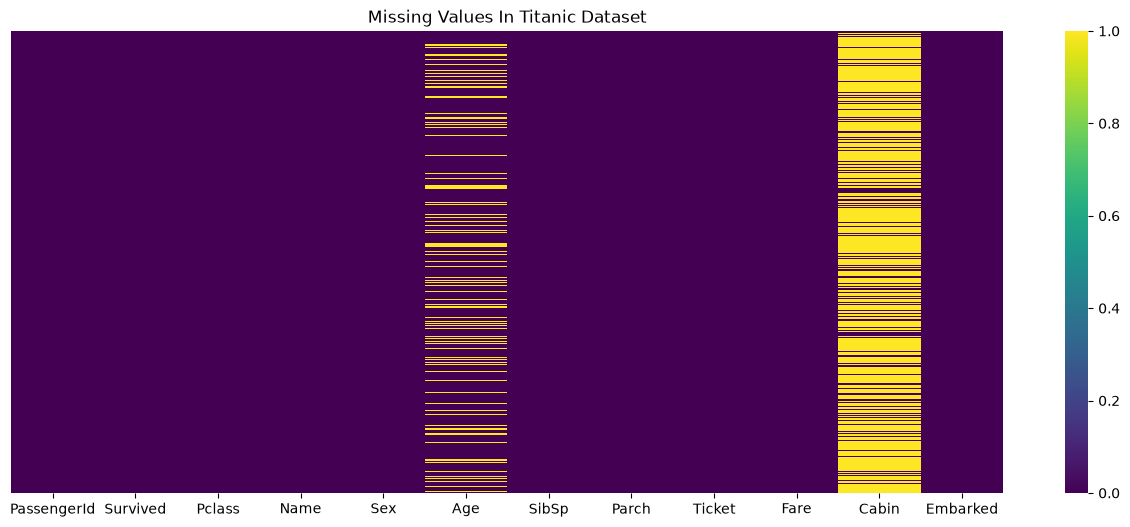

In [58]:
# let's plot missing values in the dataset

# step 1: adjusting figure size
plt.figure(figsize=(16,6))
# step 2: using seaborn to plot
sns.heatmap(df.isnull(), cmap="viridis", yticklabels=False)

# step 3: add labels
plt.title("Missing Values In Titanic Dataset")

# step 4: remove unnecessary output
plt.show()

In [59]:
# checking missing values by percentage
df.isnull().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

## Titanic Dataset Summary of Missing Values

The Titanic dataset contains a few missing values that need attention before analysis or modeling.

- **Age**: 177 missing values, which is about **19.87%** of the dataset
- **Cabin**: 687 missing values, which is about **77.10%** of the dataset
- **Embarked**: 2 missing values, which is about **0.22%** of the dataset

### Summary
The `Cabin` column has the highest number of missing values by far, while `Age` also has a significant amount of missing data. `Embarked` has only a very small number of missing entries. These missing values should be handled appropriately before further analysis.

### Dealing with Cabin column

In [60]:
# we'll drop Cabin column since it has maximum number of missing values
df.drop(columns=['Cabin'],inplace=True)
# df = df.drop(columns=['Cabin'])


In [61]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

### Dealing with Age column

In [62]:
# ignore irrelevant warnings
import warnings
warnings.filterwarnings("ignore")

In [63]:
# filling missing values in Age column with median value
df['Age'] = df['Age'].fillna(df['Age'].median())

### Dealing with Embarked Column

In [64]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [65]:
# dealing with missing values in Embarked column by filling them with mode value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


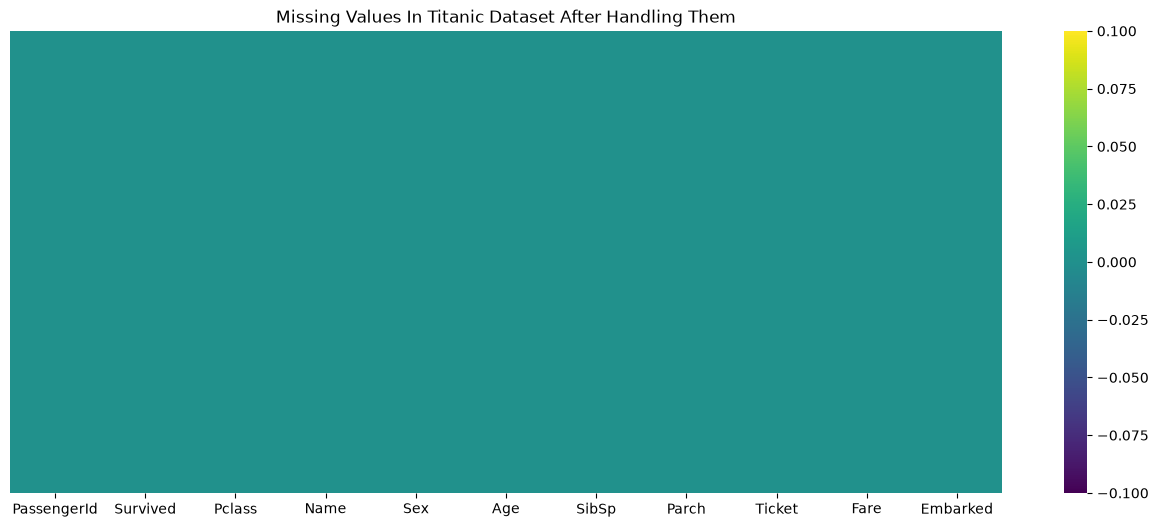

In [66]:
# plotting missing values after handling them
plt.figure(figsize=(16,6))
sns.heatmap(df.isnull(), cmap="viridis", yticklabels=False)
plt.title("Missing Values In Titanic Dataset After Handling Them")
plt.show()

In [67]:
# basic summary after cleaning
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Summary After Dealing With Missing Values

- We removed the missing values in our dataset
- We replaced missing values in Age column and Embarked Column Missing Values
- We droped Cabin column since it has maximum missing values

# 3.0 Finding Relationship In The Data

## 3.1 Univariate Analysis

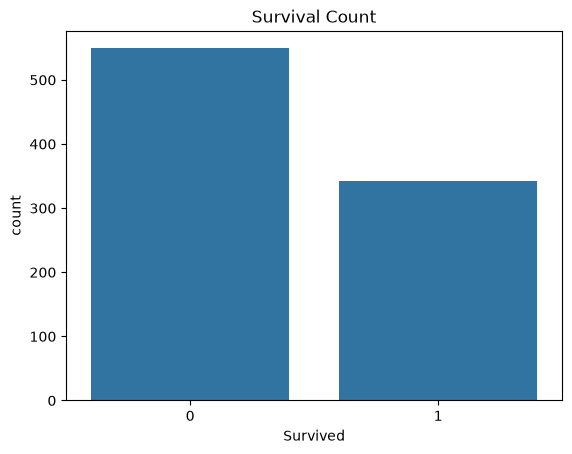

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [68]:
# target variable: survived
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

print(df["Survived"].value_counts())
print(df["Survived"].value_counts(normalize=True) * 100)

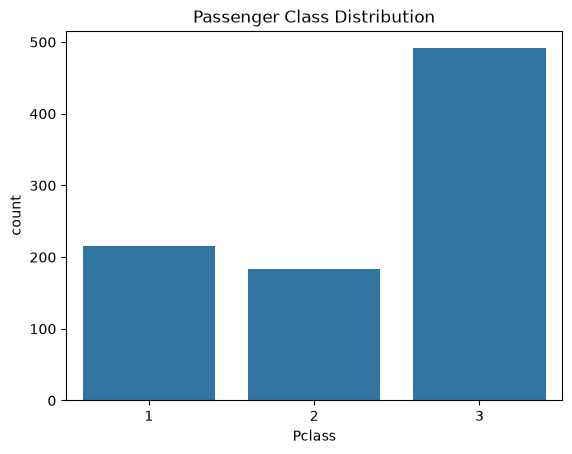

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [69]:
# passenger class
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class Distribution")
plt.show()

print(df["Pclass"].value_counts())

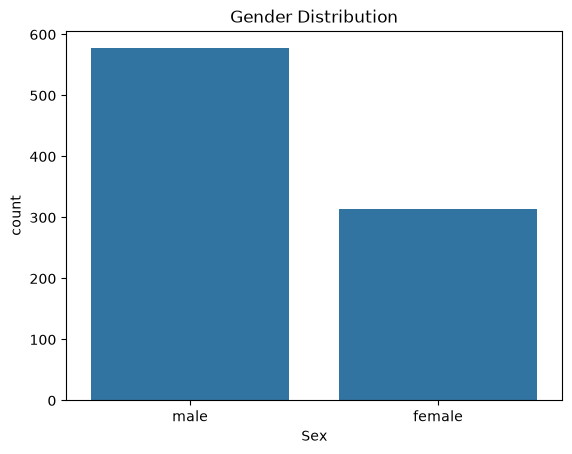

Sex
male      577
female    314
Name: count, dtype: int64


In [70]:
# sex
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

print(df["Sex"].value_counts())

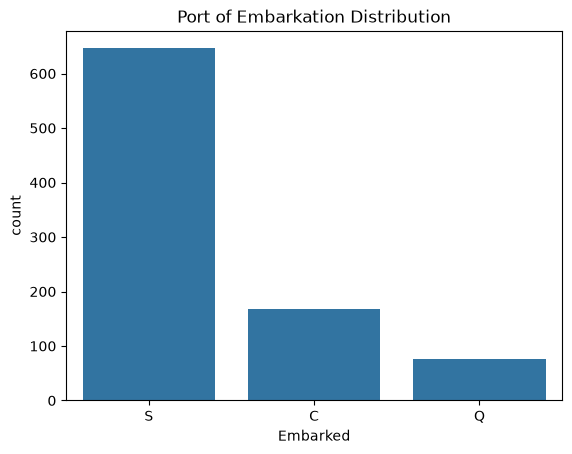

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [71]:
# embarked
sns.countplot(x="Embarked", data=df)
plt.title("Port of Embarkation Distribution")
plt.show()

print(df["Embarked"].value_counts())

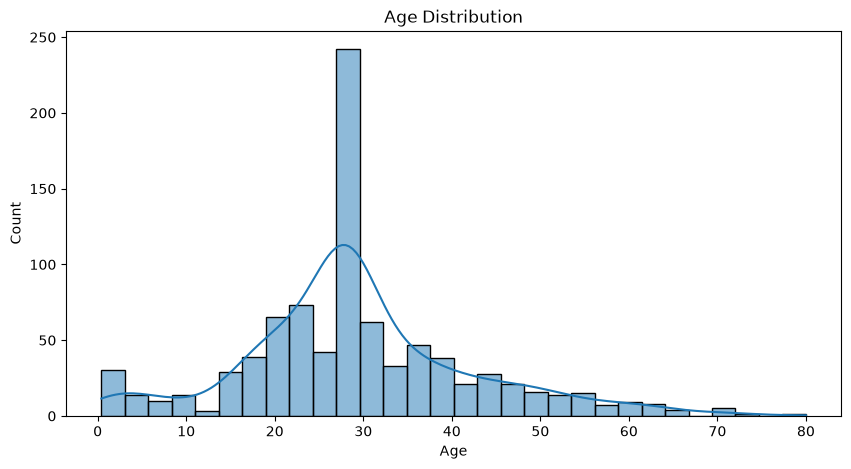

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


In [72]:
# age distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["Age"], kde=True, bins=30)
plt.title("Age Distribution")
plt.show()

print(df["Age"].describe())

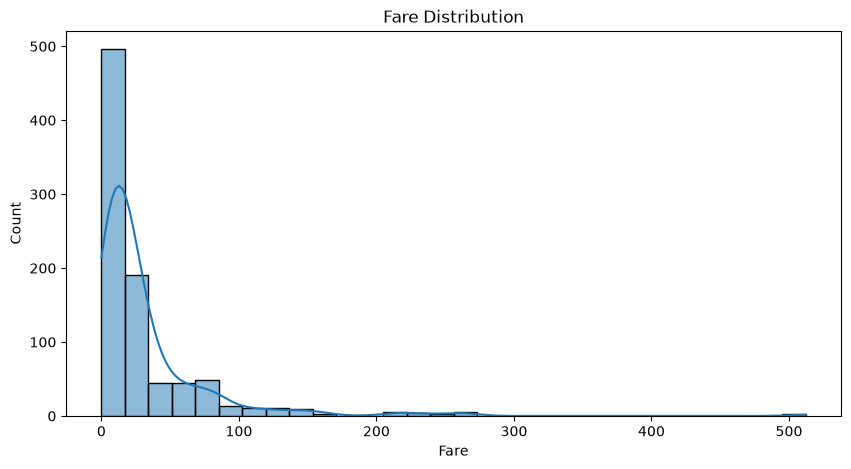

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [73]:
# fare distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["Fare"], kde=True, bins=30)
plt.title("Fare Distribution")
plt.show()

print(df["Fare"].describe())

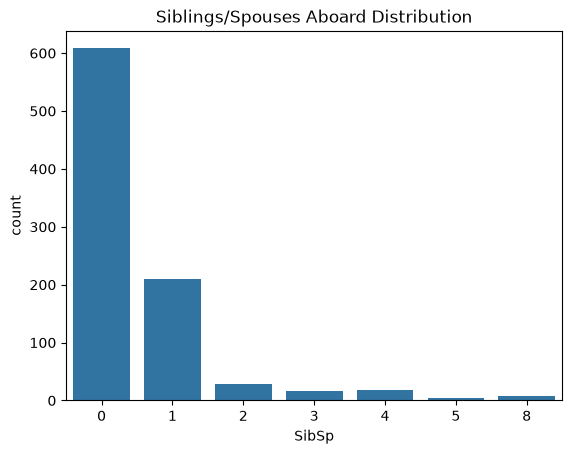

In [74]:
# sibsp distribution
sns.countplot(x="SibSp", data=df)
plt.title("Siblings/Spouses Aboard Distribution")
plt.show()

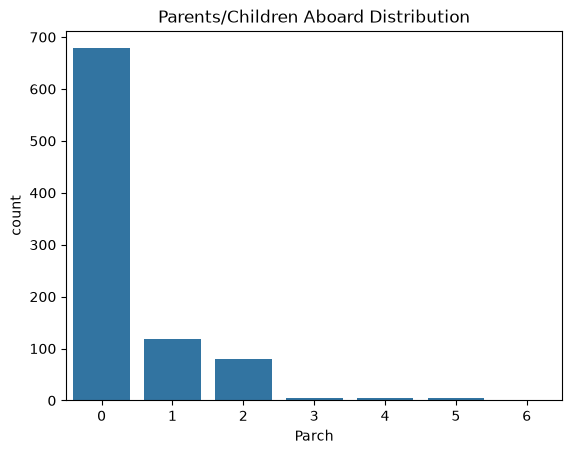

In [75]:
# parch distribution
sns.countplot(x="Parch", data=df)
plt.title("Parents/Children Aboard Distribution")
plt.show()

### 3.1 **Univariate Analysis Summary**

The univariate analysis gives a clear overview of the Titanic dataset after cleaning.

- The `Survived` column shows that more passengers did not survive than survived.
- Most passengers were in `Pclass` 3, which indicates that the largest group traveled in the lowest class.
- The dataset contains more male passengers than female passengers.
- `Age` is concentrated around young and middle-aged passengers, with fewer very young and elderly passengers.
- `Fare` is right-skewed, meaning most passengers paid relatively low fares and only a few paid very high fares.
- For `SibSp` and `Parch`, most passengers traveled alone or with only a small number of family members.
- `Embarked` is dominated by one or two ports, with fewer passengers boarding from other locations.

### Conclusion
Overall, the Titanic dataset is imbalanced in several features, especially `Survived`, `Sex`, and `Pclass`. These patterns suggest that survival may be strongly influenced by passenger class, gender, age, and fare, which should be explored further in the bivariate analysis.

In [82]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

## 3.2 Bivariate Analysis

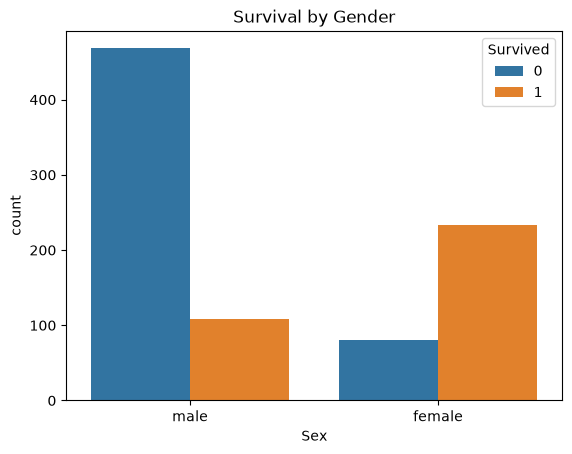

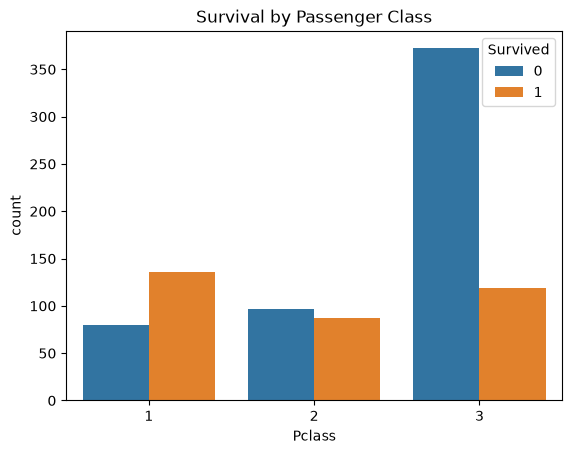

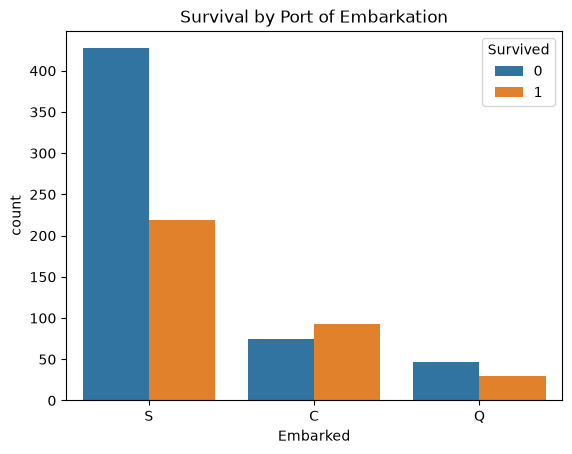

In [76]:
# 3.0 Bivariate Analysis

# survival by sex
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

# survival by passenger class
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

# survival by embarkation port
sns.countplot(x="Embarked", hue="Survived", data=df)
plt.title("Survival by Port of Embarkation")
plt.show()

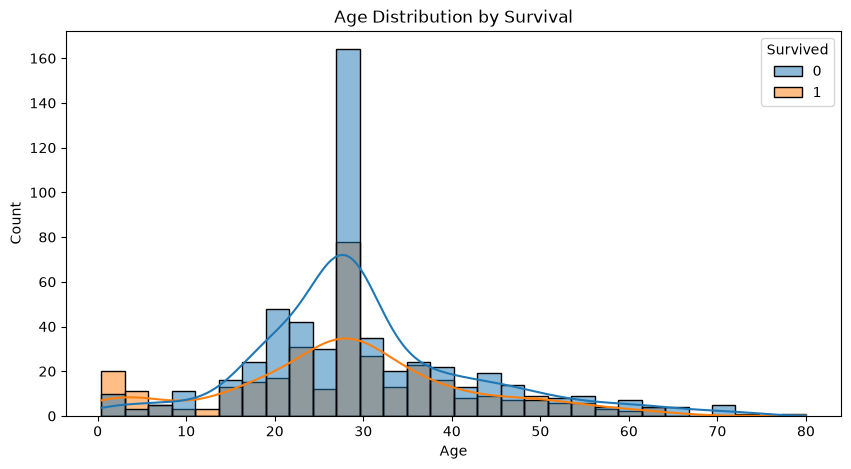

In [77]:
# age vs survival
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True, multiple="layer")
plt.title("Age Distribution by Survival")
plt.show()

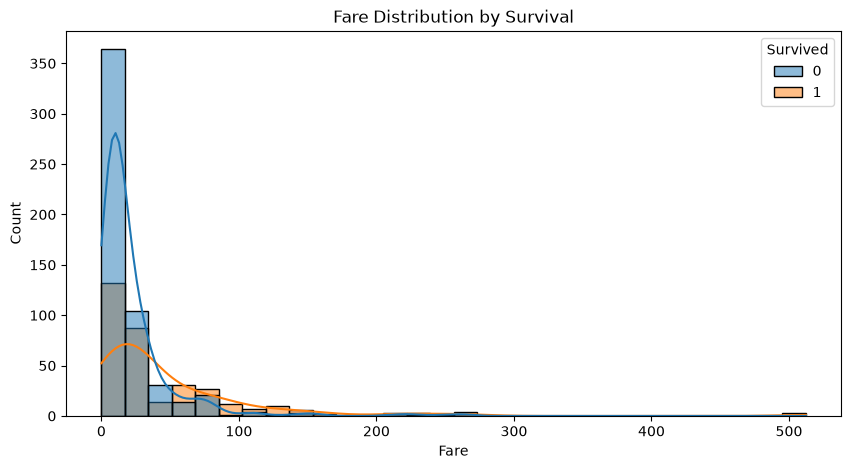

In [78]:
# fare vs survival
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Fare", hue="Survived", bins=30, kde=True, multiple="layer")
plt.title("Fare Distribution by Survival")
plt.show()

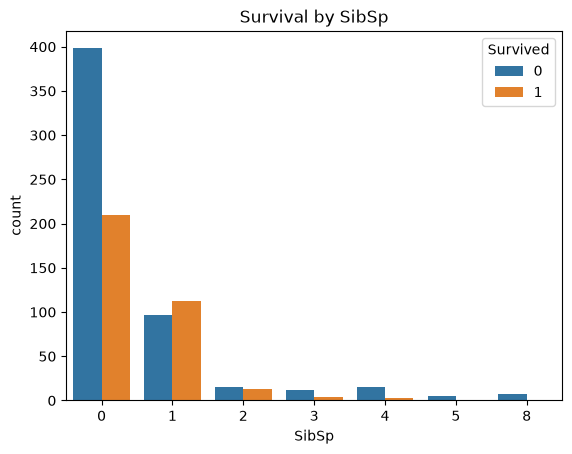

In [79]:
# survival by siblings/spouses aboard
sns.countplot(x="SibSp", hue="Survived", data=df)
plt.title("Survival by SibSp")
plt.show()

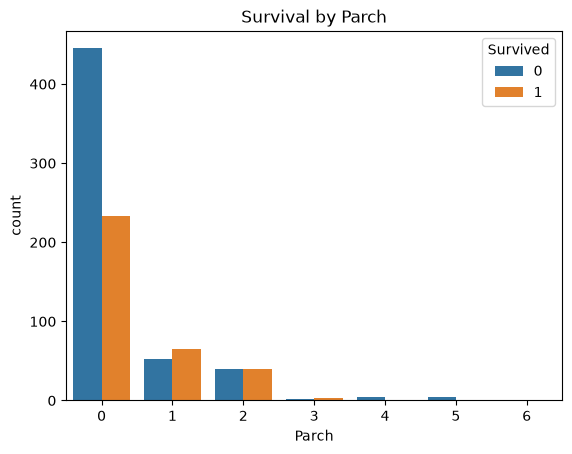

In [80]:
# survival by parents/children aboard
sns.countplot(x="Parch", hue="Survived", data=df)
plt.title("Survival by Parch")
plt.show()

## 3.2 Bivariate Analysis Summary

The bivariate analysis shows clear relationships between survival and several passenger features.

- Women had a much higher survival rate than men.
- Passengers in first class were more likely to survive than those in second and third class.
- Survival patterns also vary by port of embarkation, although the effect is weaker than sex and class.
- Younger passengers appear to have a better survival tendency than older passengers.
- Passengers who paid higher fares generally had a higher chance of survival.
- Small family groups, especially passengers with fewer siblings/spouses or parents/children aboard, show noticeable survival differences.

### Conclusion
The strongest patterns suggest that sex, passenger class, fare, and age had a major influence on survival. These relationships are important because they help explain which groups were more likely to survive the Titanic disaster.

# 4.0 Correlation Analysis

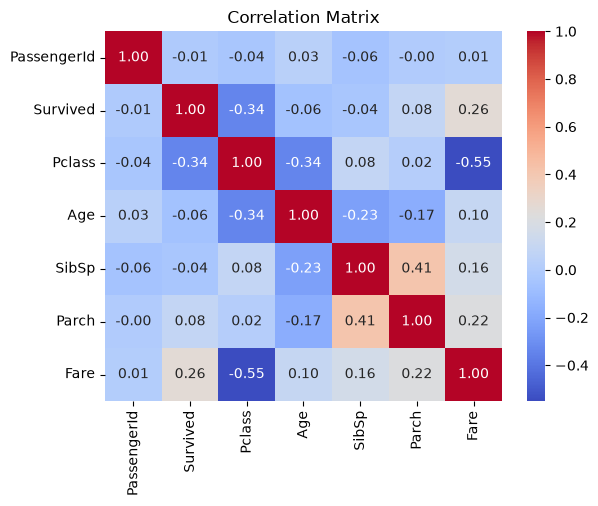

In [81]:
# correlation matrix
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## 4.1 Correlation Analysis Summary

The correlation analysis helps identify the numerical relationships between key variables in the Titanic dataset.

- `Survived` shows a positive relationship with `Fare`, which suggests that passengers who paid higher fares were more likely to survive.
- `Survived` has a negative relationship with `Pclass`, meaning passengers in higher classes had better survival chances.
- `Age` has a weak relationship with survival, indicating that age alone was not a very strong predictor.
- `SibSp` and `Parch` show only weak correlations with survival, but they may still be useful when combined into family-based features.
- `Fare` and `Pclass` are negatively correlated, which makes sense because lower class tickets were generally cheaper.
- `SibSp` and `Parch` are related to each other, since both describe family members aboard.

### Conclusion
Overall, the correlation analysis confirms that `Pclass` and `Fare` are among the most informative numerical features for survival. While `Age`, `SibSp`, and `Parch` have weaker direct correlations, they may still contribute useful information in a broader analysis or predictive model.

## 5.0 Final Conclusion

This exploratory data analysis of the Titanic dataset provided a clear picture of the structure, quality, and patterns in the data.

### Key Findings
- The dataset contained 891 rows and 12 columns, with no duplicate rows.
- Missing values were mainly found in `Cabin`, `Age`, and `Embarked`.
- `Cabin` was dropped because it had too many missing values, while `Age` and `Embarked` were filled using the median and mode.
- In the univariate analysis, most passengers were in third class, more passengers were male, and most fares were relatively low.
- The bivariate analysis showed strong relationships between survival and features such as `Sex`, `Pclass`, `Age`, and `Fare`.
- Women, first-class passengers, younger passengers, and those who paid higher fares had better chances of survival.
- Smaller family groups also showed noticeable differences in survival patterns.

### Overall Conclusion
The Titanic dataset shows that survival was not random. It was strongly influenced by passenger class, gender, age, and fare. These insights make the dataset useful for both exploratory analysis and predictive modeling.

### Final Insight
If this dataset is used for machine learning, the most important features are likely to be `Sex`, `Pclass`, `Age`, `Fare`, `SibSp`, `Parch`, and `Embarked`.